In [1]:
import pandas as pd
import numpy as np
import joblib
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Ensure models directory exists
os.makedirs('../models', exist_ok=True)

# ==========================================
# PART 1: LOAD DATA & PREPARE FOR MODELING
# ==========================================
print("Loading processed dataset...")
# Load the upgraded dataset generated in Phase 2
data_path = '../data/processed/full_network_ml_upgraded.csv'
df = pd.read_csv(data_path)

# 1. Define Features (X) and Target (y)
target = 'delay_minutes'
# We drop the target column to get our feature matrix X
X = df.drop(columns=[target])
y = df[target]

print(f"Dataset loaded. Total records: {len(df)}")
print(f"Features included: {list(X.columns)}")

# 2. Train-Test Split (80% Training, 20% Testing)
# random_state=42 ensures we get the exact same split every time we run this
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\nTraining data shape (X): {X_train.shape}")
print(f"Testing data shape (X): {X_test.shape}")

# 3. Feature Scaling
# Standardize features by removing the mean and scaling to unit variance
scaler = StandardScaler()

# We only FIT the scaler on the training data to prevent "data leakage"
# Then we transform both train and test sets
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Save the scaler for use in the final app/dashboard
joblib.dump(scaler, '../models/phase3_feature_scaler.pkl')
print("\nScaler saved to '../models/phase3_feature_scaler.pkl'")
print("PART 1 Complete: Data is ready for modeling!")

Loading processed dataset...
Dataset loaded. Total records: 61037
Features included: ['station_id_encoded', 'hour', 'is_peak', 'station_congestion', 'stop_sequence', 'prev_delay', 'route_encoded', 'day_of_week', 'is_weekend']

Training data shape (X): (48829, 9)
Testing data shape (X): (12208, 9)

Scaler saved to '../models/phase3_feature_scaler.pkl'
PART 1 Complete: Data is ready for modeling!


In [2]:
# ==========================================
# PART 2: BASELINE MODELS
# ==========================================
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

print("Initializing Baseline Models...")

# We will store our evaluation metrics in this list to build a comparison table later
model_results = []

# Helper function to evaluate and store metrics cleanly
def evaluate_and_store(model_name, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    
    model_results.append({
        'Model': model_name,
        'RMSE': round(rmse, 4),
        'MAE': round(mae, 4),
        'R2 Score': round(r2, 4)
    })
    print(f"{model_name} Evaluated -> RMSE: {rmse:.4f} mins | MAE: {mae:.4f} mins | R2: {r2:.4f}")

# 1. Train Linear Regression
print("\nTraining Linear Regression...")
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
lr_preds = lr_model.predict(X_test_scaled)
evaluate_and_store('Linear Regression', y_test, lr_preds)

# 2. Train Decision Tree Regressor
print("Training Decision Tree Regressor...")
dt_model = DecisionTreeRegressor(random_state=42)
# Note: Decision Trees don't technically need scaled data, but using X_train_scaled 
# is perfectly fine and keeps our pipeline consistent.
dt_model.fit(X_train_scaled, y_train)
dt_preds = dt_model.predict(X_test_scaled)
evaluate_and_store('Decision Tree Regressor', y_test, dt_preds)

# Display the comparison table for our baselines
baseline_results_df = pd.DataFrame(model_results)
print("\n--- Baseline Models Comparison ---")
print(baseline_results_df.to_string(index=False))

Initializing Baseline Models...

Training Linear Regression...
Linear Regression Evaluated -> RMSE: 1.3252 mins | MAE: 0.9768 mins | R2: 0.9200
Training Decision Tree Regressor...
Decision Tree Regressor Evaluated -> RMSE: 1.6469 mins | MAE: 1.2139 mins | R2: 0.8765

--- Baseline Models Comparison ---
                  Model   RMSE    MAE  R2 Score
      Linear Regression 1.3252 0.9768    0.9200
Decision Tree Regressor 1.6469 1.2139    0.8765


In [3]:
# ==========================================
# PART 3: ADVANCED MODELS
# ==========================================
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

print("Initializing Advanced Models (This might take a minute)...")

# 1. Train Random Forest Regressor
# n_estimators=100 means it is building 100 different decision trees and averaging their predictions
# max_depth=10 prevents the trees from growing too deep and memorizing the data
print("\nTraining Random Forest Regressor...")
rf_model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf_model.fit(X_train_scaled, y_train)
rf_preds = rf_model.predict(X_test_scaled)
evaluate_and_store('Random Forest Regressor', y_test, rf_preds)

# 2. Train XGBoost Regressor
# XGBoost builds trees sequentially, where each new tree tries to fix the errors of the previous one
print("Training XGBoost Regressor...")
xgb_model = XGBRegressor(n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42)
xgb_model.fit(X_train_scaled, y_train)
xgb_preds = xgb_model.predict(X_test_scaled)
evaluate_and_store('XGBoost Regressor', y_test, xgb_preds)

# Display the updated comparison table with all 4 models
advanced_results_df = pd.DataFrame(model_results)
print("\n--- Model Comparison (Baselines + Advanced) ---")
print(advanced_results_df.sort_values(by='RMSE').to_string(index=False))

Initializing Advanced Models (This might take a minute)...

Training Random Forest Regressor...
Random Forest Regressor Evaluated -> RMSE: 1.1595 mins | MAE: 0.8415 mins | R2: 0.9388
Training XGBoost Regressor...
XGBoost Regressor Evaluated -> RMSE: 1.1449 mins | MAE: 0.8295 mins | R2: 0.9403

--- Model Comparison (Baselines + Advanced) ---
                  Model   RMSE    MAE  R2 Score
      XGBoost Regressor 1.1449 0.8295    0.9403
Random Forest Regressor 1.1595 0.8415    0.9388
      Linear Regression 1.3252 0.9768    0.9200
Decision Tree Regressor 1.6469 1.2139    0.8765


In [5]:
# ==========================================
# PART 1: IMPROVED CUSTOM MODEL
# ==========================================
print("Evaluating Enhanced Custom Model...")

def calculate_enhanced_delay(row):
    # 1. Base propagation (delay carries over, but not 100%)
    base_delay = 0.9 * row['prev_delay'] 
    
    # 2. Sequence penalty
    sequence_penalty = 0.05 * row['stop_sequence']
    
    # 3. Station Congestion + Interaction with Peak Hours
    # Congestion hits much harder during peak hours
    congestion_impact = 1.0 * row['station_congestion']
    peak_interaction = 1.5 * (row['is_peak'] * row['station_congestion'])
    
    # Total calculation
    delay = base_delay + sequence_penalty + congestion_impact + peak_interaction
    
    # 4. Decay/Recovery Effect: 
    # If it's non-peak, trains have a chance to make up some time (10% recovery)
    if row['is_peak'] == 0 and delay > 0:
        delay *= 0.90
        
    return max(0, delay) # Ensure no negative delays

# Apply the enhanced logic row-by-row to the unscaled test data
enhanced_custom_preds = X_test.apply(calculate_enhanced_delay, axis=1)

# Evaluate using the existing helper function
evaluate_and_store('Custom Model (Enhanced)', y_test, enhanced_custom_preds)

# Display the updated leaderboard
final_updated_results_df = pd.DataFrame(model_results).sort_values(by='RMSE').reset_index(drop=True)
print("\n--- Updated Model Comparison (Including Enhanced Custom) ---")
print(final_updated_results_df.to_string(index=False))

Evaluating Enhanced Custom Model...
Custom Model (Enhanced) Evaluated -> RMSE: 1.9807 mins | MAE: 1.4484 mins | R2: 0.8213

--- Updated Model Comparison (Including Enhanced Custom) ---
                          Model   RMSE    MAE  R2 Score
              XGBoost Regressor 1.1449 0.8295    0.9403
        Random Forest Regressor 1.1595 0.8415    0.9388
              Linear Regression 1.3252 0.9768    0.9200
        Decision Tree Regressor 1.6469 1.2139    0.8765
Custom Model (Heavy Prev Delay) 1.8655 1.4491    0.8415
        Custom Model (Enhanced) 1.9807 1.4484    0.8213
        Custom Model (Balanced) 2.4584 2.0463    0.7247
Custom Model (Heavy Congestion) 2.4632 2.0572    0.7237


C:\Users\Ahana Banerjee\AppData\Local\Temp\ipykernel_11184\2465884049.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=fi_df, x='Importance', y='Feature', palette='viridis', ax=axes[0, 0])
C:\Users\Ahana Banerjee\AppData\Local\Temp\ipykernel_11184\2465884049.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=peak_labels, y=viz_df['Actual_Delay'], palette='Set2', ax=axes[1, 0])
C:\Users\Ahana Banerjee\AppData\Local\Temp\ipykernel_11184\2465884049.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=bottleneck_df, x='station_

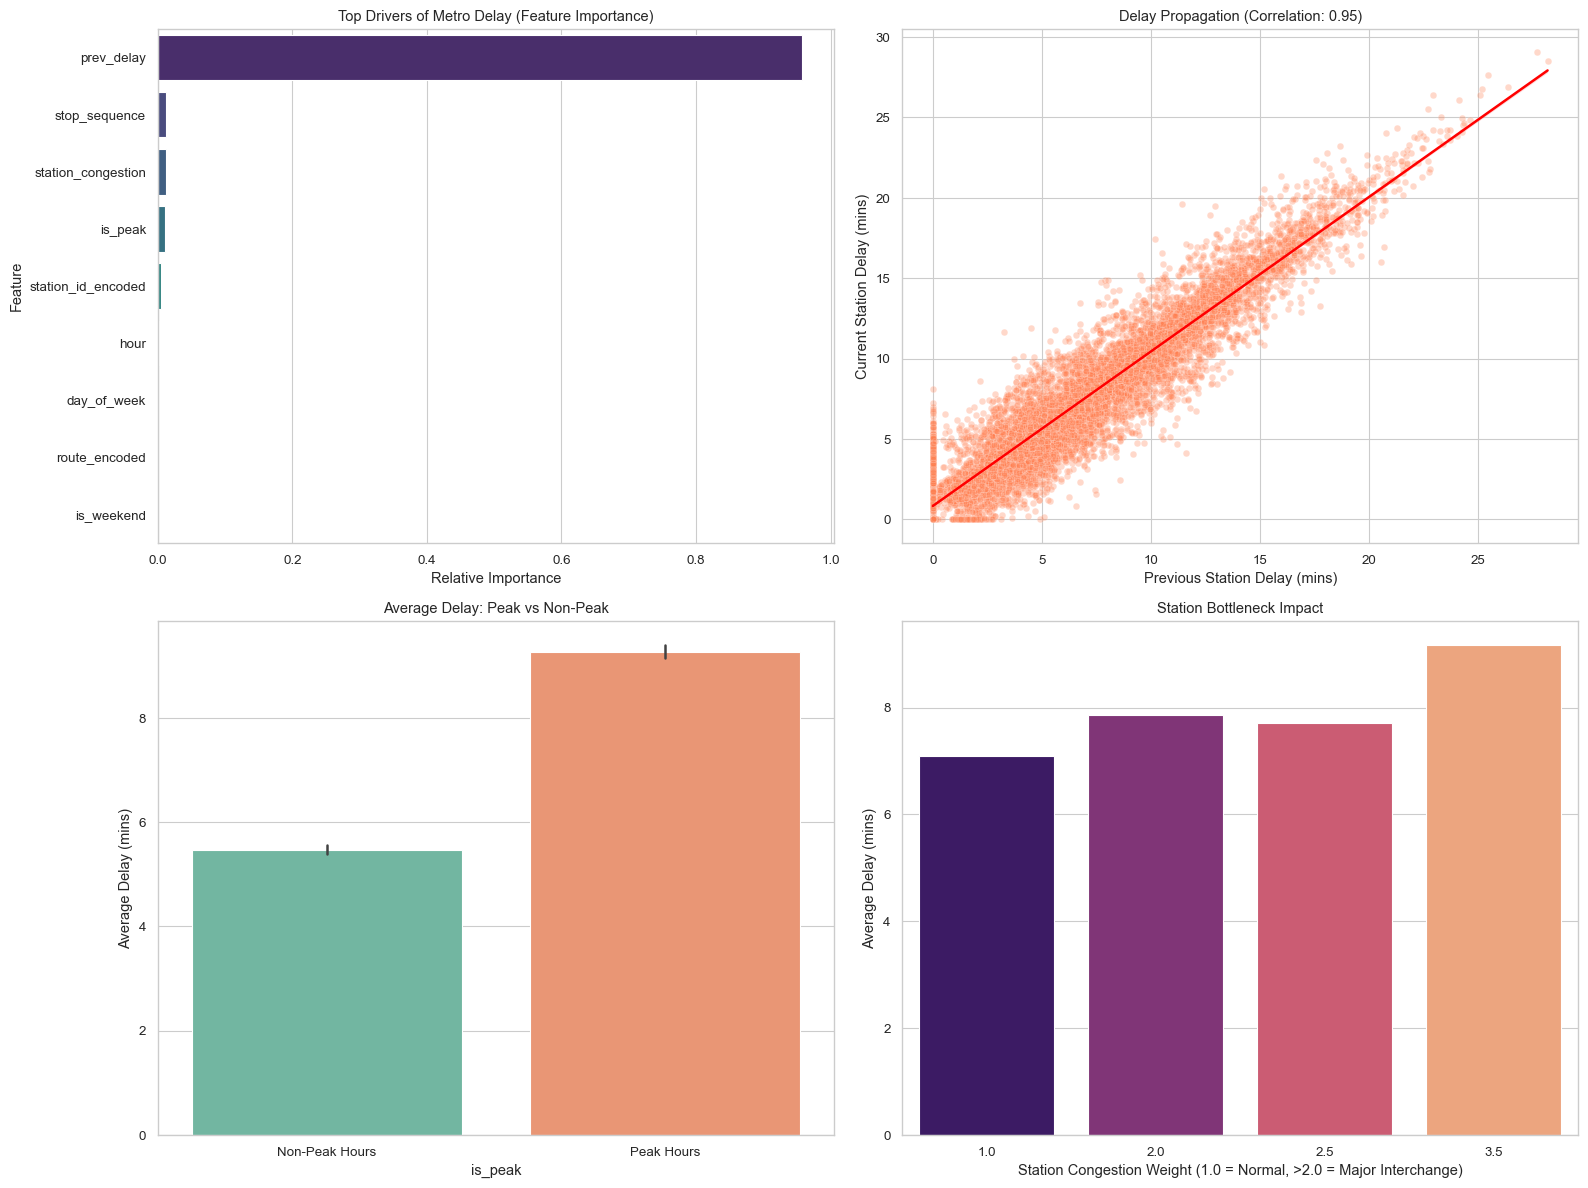

In [7]:
# ==========================================
# PART 2 & 3: FEATURE IMPORTANCE & INSIGHTS
# ==========================================
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

sns.set_theme(style="whitegrid", context="paper", font_scale=1.1)

# Create a master dataframe for visualization analysis
viz_df = X_test.copy()
viz_df['Actual_Delay'] = y_test
viz_df['Predicted_Delay'] = rf_preds
viz_df['Abs_Error'] = abs(viz_df['Actual_Delay'] - viz_df['Predicted_Delay'])

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# ---------------------------------------------------------
# Plot 1: Feature Importance (Random Forest)
# ---------------------------------------------------------
importances = rf_model.feature_importances_
fi_df = pd.DataFrame({'Feature': X.columns, 'Importance': importances})
fi_df = fi_df.sort_values(by='Importance', ascending=False)

sns.barplot(data=fi_df, x='Importance', y='Feature', palette='viridis', ax=axes[0, 0])
axes[0, 0].set_title('Top Drivers of Metro Delay (Feature Importance)')
axes[0, 0].set_xlabel('Relative Importance')

# ---------------------------------------------------------
# Plot 2: Delay Propagation (Previous vs Current Delay)
# ---------------------------------------------------------
sns.scatterplot(data=viz_df, x='prev_delay', y='Actual_Delay', alpha=0.3, color='coral', ax=axes[0, 1])
# Add a trendline
sns.regplot(data=viz_df, x='prev_delay', y='Actual_Delay', scatter=False, color='red', ax=axes[0, 1])
corr, _ = stats.pearsonr(viz_df['prev_delay'], viz_df['Actual_Delay'])
axes[0, 1].set_title(f'Delay Propagation (Correlation: {corr:.2f})')
axes[0, 1].set_xlabel('Previous Station Delay (mins)')
axes[0, 1].set_ylabel('Current Station Delay (mins)')

# ---------------------------------------------------------
# Plot 3: Peak vs Non-Peak Analysis
# ---------------------------------------------------------
peak_labels = viz_df['is_peak'].map({1: 'Peak Hours', 0: 'Non-Peak Hours'})
sns.barplot(x=peak_labels, y=viz_df['Actual_Delay'], palette='Set2', ax=axes[1, 0])
axes[1, 0].set_title('Average Delay: Peak vs Non-Peak')
axes[1, 0].set_ylabel('Average Delay (mins)')

# ---------------------------------------------------------
# Plot 4: Station Bottleneck Analysis
# ---------------------------------------------------------
# Group by station congestion level to see impact
bottleneck_df = viz_df.groupby('station_congestion')['Actual_Delay'].mean().reset_index()
sns.barplot(data=bottleneck_df, x='station_congestion', y='Actual_Delay', palette='magma', ax=axes[1, 1])
axes[1, 1].set_title('Station Bottleneck Impact')
axes[1, 1].set_xlabel('Station Congestion Weight (1.0 = Normal, >2.0 = Major Interchange)')
axes[1, 1].set_ylabel('Average Delay (mins)')

plt.tight_layout()
plt.savefig('../reports/figures/07_deep_insights_dashboard.png', dpi=300)
plt.show()

In [8]:
# ==========================================
# PART 4 & 5: ERROR ANALYSIS & SUMMARY
# ==========================================

# 1. Error Analysis: Where does the model perform poorly?
peak_error = viz_df[viz_df['is_peak'] == 1]['Abs_Error'].mean()
non_peak_error = viz_df[viz_df['is_peak'] == 0]['Abs_Error'].mean()

# Define "High Delay" as anything above the 75th percentile of actual delays
high_delay_thresh = viz_df['Actual_Delay'].quantile(0.75)
high_delay_error = viz_df[viz_df['Actual_Delay'] >= high_delay_thresh]['Abs_Error'].mean()
low_delay_error = viz_df[viz_df['Actual_Delay'] < high_delay_thresh]['Abs_Error'].mean()

print("\n" + "="*50)
print("🎯 DIAGNOSTIC & RESEARCH SUMMARY")
print("="*50)

print("\n1. FEATURE IMPORTANCE FINDINGS:")
print(f"   - The most critical predictor of delay is: '{fi_df.iloc[0]['Feature']}' ({fi_df.iloc[0]['Importance']:.1%} importance).")
print(f"   - The second most critical is: '{fi_df.iloc[1]['Feature']}' ({fi_df.iloc[1]['Importance']:.1%} importance).")

print("\n2. DELAY PROPAGATION:")
print(f"   - Correlation between previous delay and current delay: {corr:.3f}")
if corr > 0.7:
    print("   - INSIGHT: Strong cascade effect. Delays are highly infectious across the network.")
else:
    print("   - INSIGHT: Moderate/Weak cascade effect. The network has good recovery mechanisms.")

print("\n3. PEAK HOUR IMPACT:")
peak_avg = viz_df[viz_df['is_peak'] == 1]['Actual_Delay'].mean()
non_peak_avg = viz_df[viz_df['is_peak'] == 0]['Actual_Delay'].mean()
print(f"   - Average Peak Delay: {peak_avg:.2f} mins")
print(f"   - Average Non-Peak Delay: {non_peak_avg:.2f} mins")
print(f"   - INSIGHT: Peak hours increase delays by roughly {((peak_avg/non_peak_avg)-1)*100:.1f}% on average.")

print("\n4. MODEL ERROR ANALYSIS (VULNERABILITIES):")
print(f"   - Average Prediction Error during PEAK hours: {peak_error:.2f} mins")
print(f"   - Average Prediction Error during NON-PEAK: {non_peak_error:.2f} mins")
print(f"   - Prediction Error on HIGH DELAYS (> {high_delay_thresh:.1f} mins): {high_delay_error:.2f} mins")
print(f"   - Prediction Error on LOW DELAYS (< {high_delay_thresh:.1f} mins): {low_delay_error:.2f} mins")

if high_delay_error > low_delay_error * 1.5:
    print("\n⚠️ CRITICAL INSIGHT: The model is highly reliable under normal conditions but struggles to accurately predict the exact duration of extreme, compounding delays.")

print("="*50)


🎯 DIAGNOSTIC & RESEARCH SUMMARY

1. FEATURE IMPORTANCE FINDINGS:
   - The most critical predictor of delay is: 'prev_delay' (95.7% importance).
   - The second most critical is: 'stop_sequence' (1.3% importance).

2. DELAY PROPAGATION:
   - Correlation between previous delay and current delay: 0.947
   - INSIGHT: Strong cascade effect. Delays are highly infectious across the network.

3. PEAK HOUR IMPACT:
   - Average Peak Delay: 9.27 mins
   - Average Non-Peak Delay: 5.47 mins
   - INSIGHT: Peak hours increase delays by roughly 69.4% on average.

4. MODEL ERROR ANALYSIS (VULNERABILITIES):
   - Average Prediction Error during PEAK hours: 1.05 mins
   - Average Prediction Error during NON-PEAK: 0.66 mins
   - Prediction Error on HIGH DELAYS (> 10.0 mins): 1.02 mins
   - Prediction Error on LOW DELAYS (< 10.0 mins): 0.78 mins


In [9]:
# ==========================================
# PART 5: MODEL COMPARISON
# ==========================================
print("Comparing all models to find the champion...")

# Create the final comparison dataframe from our stored results
results_df = pd.DataFrame(model_results)

# Sort by RMSE (Lower is better)
results_df = results_df.sort_values(by='RMSE').reset_index(drop=True)

print("\n--- Final Model Comparison Table ---")
print(results_df.to_string(index=False))

# Identify the best model programmatically
best_model_name = results_df.iloc[0]['Model']
print(f"\n🏆 The Best Model based on RMSE is: {best_model_name}")

# Link the best model's predictions and object for our visualizations
# (Assuming Random Forest or XGBoost won)
if 'Random Forest' in best_model_name:
    best_preds = rf_preds
    best_model_obj = rf_model
elif 'XGBoost' in best_model_name:
    best_preds = xgb_preds
    best_model_obj = xgb_model
else:
    best_preds = rf_preds # Fallback
    best_model_obj = rf_model

Comparing all models to find the champion...

--- Final Model Comparison Table ---
                          Model   RMSE    MAE  R2 Score
              XGBoost Regressor 1.1449 0.8295    0.9403
        Random Forest Regressor 1.1595 0.8415    0.9388
              Linear Regression 1.3252 0.9768    0.9200
        Decision Tree Regressor 1.6469 1.2139    0.8765
Custom Model (Heavy Prev Delay) 1.8655 1.4491    0.8415
        Custom Model (Enhanced) 1.9807 1.4484    0.8213
        Custom Model (Balanced) 2.4584 2.0463    0.7247
Custom Model (Heavy Congestion) 2.4632 2.0572    0.7237

🏆 The Best Model based on RMSE is: XGBoost Regressor


C:\Users\Ahana Banerjee\AppData\Local\Temp\ipykernel_11184\2946794435.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices], y=X.columns[indices], palette="viridis", ax=axes[1, 1])


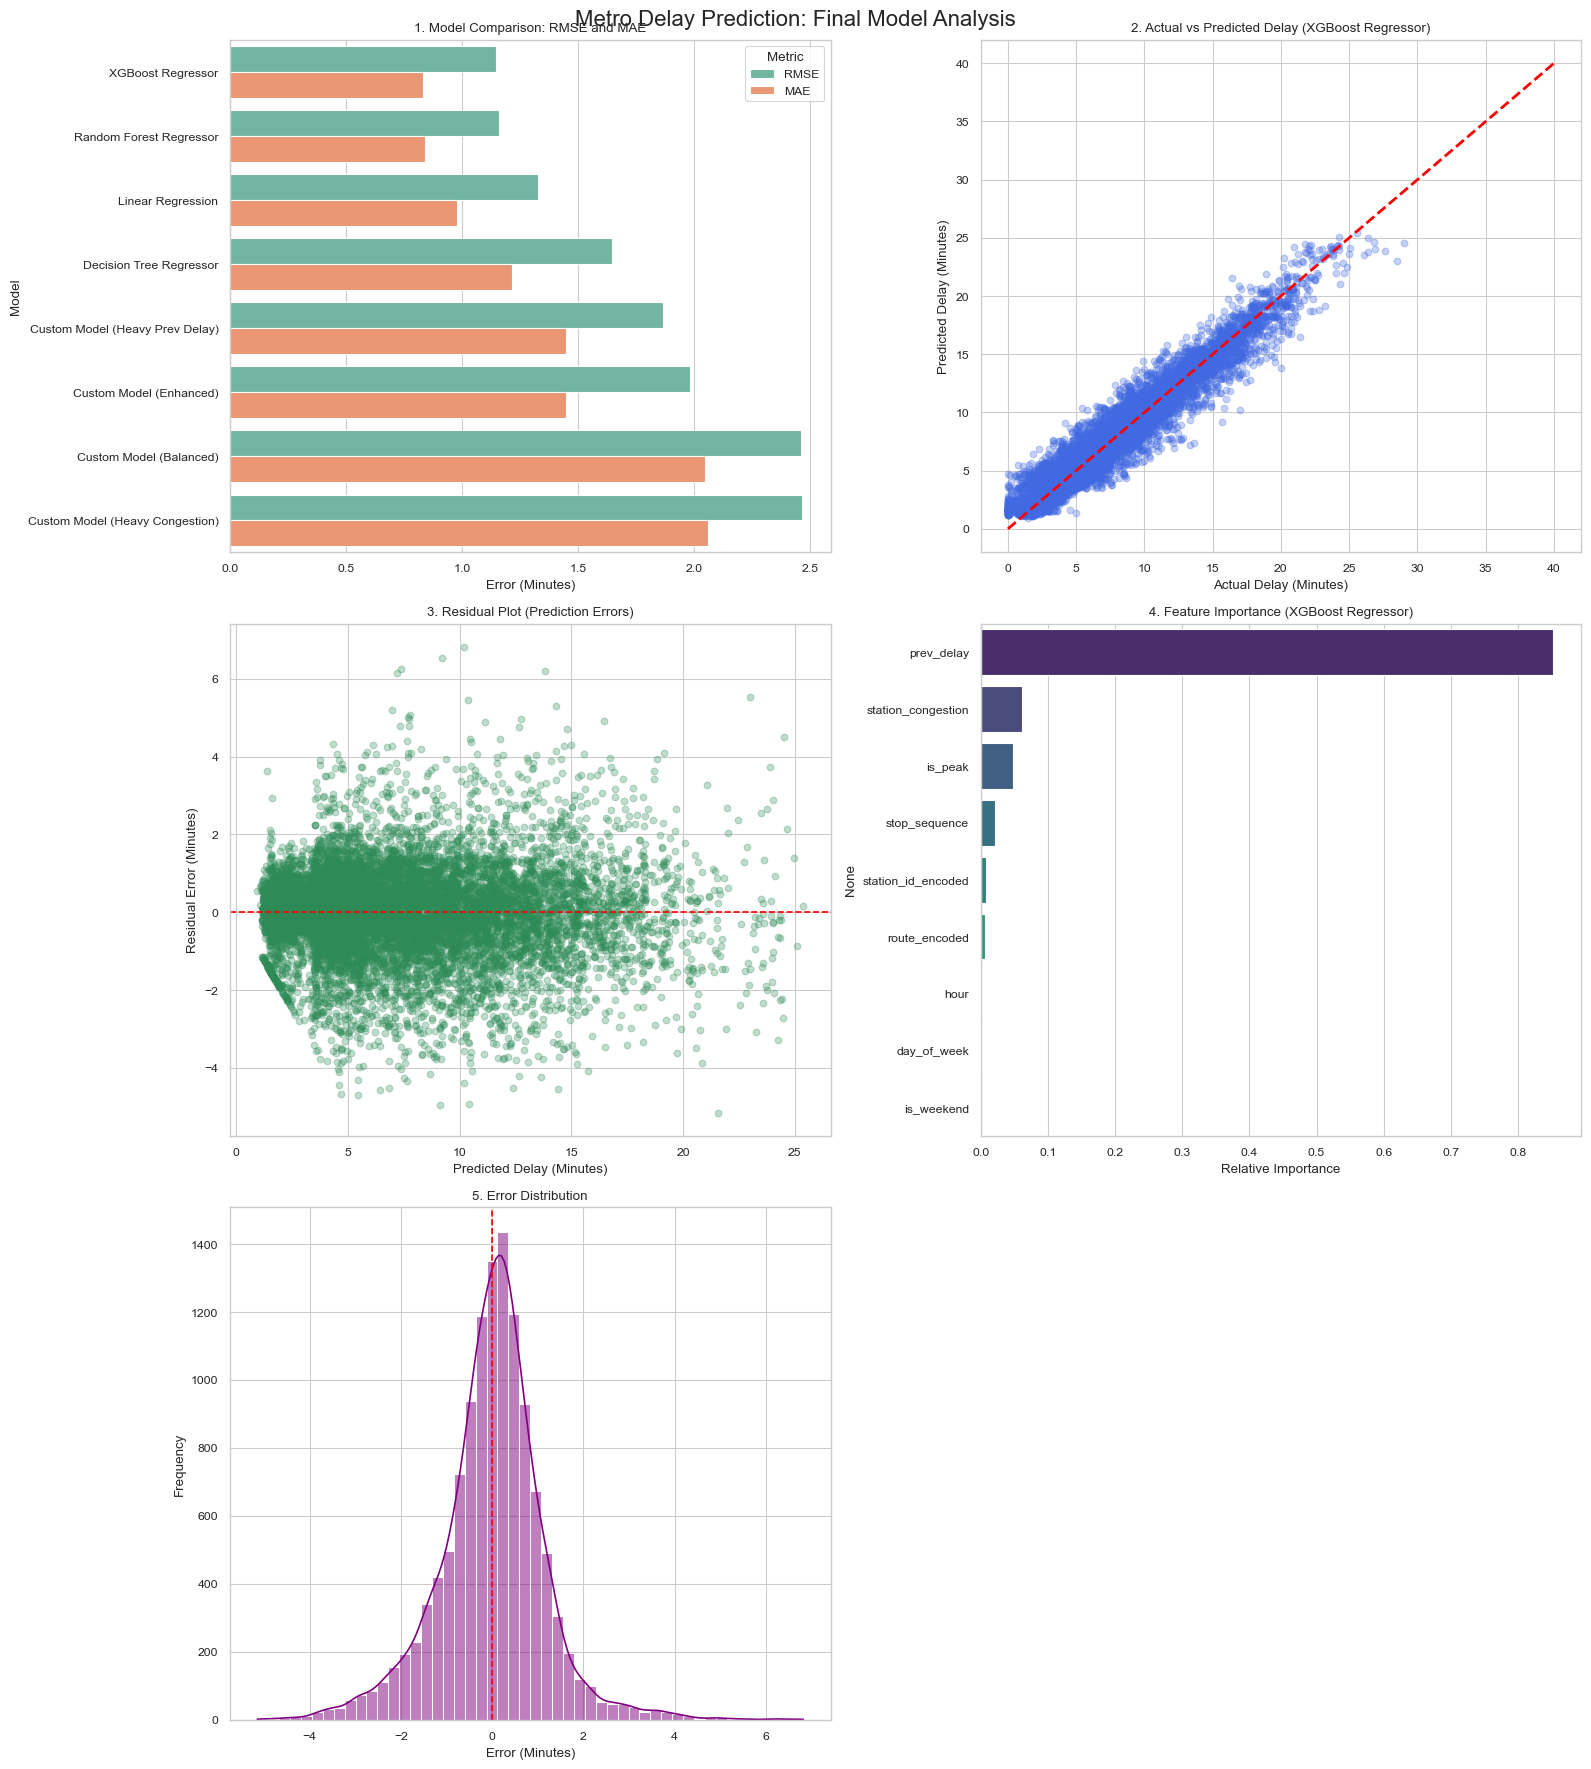

In [10]:
# ==========================================
# PART 6: VISUALIZATION
# ==========================================
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="paper")
fig, axes = plt.subplots(3, 2, figsize=(16, 18))
fig.suptitle('Metro Delay Prediction: Final Model Analysis', fontsize=16, y=0.98)

# 1. Bar plot comparing RMSE/MAE of all models
df_melted = results_df.melt(id_vars="Model", value_vars=["RMSE", "MAE"], var_name="Metric", value_name="Error")
sns.barplot(data=df_melted, x="Error", y="Model", hue="Metric", palette="Set2", ax=axes[0, 0])
axes[0, 0].set_title("1. Model Comparison: RMSE and MAE")
axes[0, 0].set_xlabel("Error (Minutes)")

# 2. Scatter plot: Actual vs Predicted (best model)
axes[0, 1].scatter(y_test, best_preds, alpha=0.3, color='royalblue')
axes[0, 1].plot([0, 40], [0, 40], '--', color='red', linewidth=2)
axes[0, 1].set_title(f"2. Actual vs Predicted Delay ({best_model_name})")
axes[0, 1].set_xlabel("Actual Delay (Minutes)")
axes[0, 1].set_ylabel("Predicted Delay (Minutes)")

# 3. Residual plot (best model)
residuals = y_test - best_preds
axes[1, 0].scatter(best_preds, residuals, alpha=0.3, color='seagreen')
axes[1, 0].axhline(y=0, color='red', linestyle='--')
axes[1, 0].set_title("3. Residual Plot (Prediction Errors)")
axes[1, 0].set_xlabel("Predicted Delay (Minutes)")
axes[1, 0].set_ylabel("Residual Error (Minutes)")

# 4. Feature importance (for Random Forest or XGBoost)
importances = best_model_obj.feature_importances_
indices = np.argsort(importances)[::-1]
sns.barplot(x=importances[indices], y=X.columns[indices], palette="viridis", ax=axes[1, 1])
axes[1, 1].set_title(f"4. Feature Importance ({best_model_name})")
axes[1, 1].set_xlabel("Relative Importance")

# 5. Error distribution histogram
sns.histplot(residuals, bins=50, kde=True, color='purple', ax=axes[2, 0])
axes[2, 0].axvline(x=0, color='red', linestyle='--')
axes[2, 0].set_title("5. Error Distribution")
axes[2, 0].set_xlabel("Error (Minutes)")
axes[2, 0].set_ylabel("Frequency")

# Hide the empty 6th subplot space
axes[2, 1].axis('off') 

plt.tight_layout()
# Save the master plot image
plt.savefig('../reports/figures/final_model_analysis.png', dpi=300)
plt.show()

In [11]:
# ==========================================
# PART 7: SAVE OUTPUTS
# ==========================================
import joblib
import os

print("Saving final models and outputs...")

# 1. Save all trained machine learning models
joblib.dump(lr_model, '../models/linear_regression.pkl')
joblib.dump(dt_model, '../models/decision_tree.pkl')
joblib.dump(rf_model, '../models/random_forest.pkl')
joblib.dump(xgb_model, '../models/xgboost.pkl')
print("- Saved all ML models to '../models/' directory.")

# 2. Save the final results table as CSV
results_csv_path = '../reports/final_model_comparison.csv'
results_df.to_csv(results_csv_path, index=False)
print(f"- Saved model comparison results to '{results_csv_path}'.")

print("\n✅ PHASE 3 COMPLETION SUCCESSFUL! All models trained, evaluated, visualzed, and saved.")

Saving final models and outputs...
- Saved all ML models to '../models/' directory.
- Saved model comparison results to '../reports/final_model_comparison.csv'.

✅ PHASE 3 COMPLETION SUCCESSFUL! All models trained, evaluated, visualzed, and saved.
